In [152]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel

import category_encoders as ce

In [153]:
df = pd.read_csv('../datasets/kingametric_credit_risk.csv')

In [154]:
df.head()

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,...,Debt_Stress_Index,Repayment_Stress,Credit_Exposure,Liquidity_Buffer,Behavioral_Risk_Composite,Credit_Instability,Payment_Instability,Net_Cash_Flow,Obligation_Ratio,Credit_Depth
0,34847.84,3037.986667,2,4,6,1,3,1,5.42,5,...,0.0174,0.003096,103.707287,0.153499,0.0,27.10,3,3019.170452,0.006192,5
1,34847.84,3037.986667,2,4,6,1,3,3,5.42,5,...,0.0174,0.006192,120.466402,0.093629,0.0,27.10,9,3019.170452,0.006192,5
2,30689.89,2612.490833,2,5,4,1,5,6,1.99,4,...,0.0206,0.006281,184.122339,0.121115,0.0,7.96,30,2596.075382,0.006281,6
3,4148862.00,2612.490833,2,5,4,1,6,6,1.99,7,...,0.0002,0.006281,177.896325,0.108852,0.0,13.93,36,2596.075382,0.006281,6
4,31370.80,2825.233333,1,6,12,2,2,3,5.76,5,...,0.0134,0.016494,203.124578,0.116717,0.0,28.80,6,2778.617204,0.016494,8


In [155]:
df.shape

(8744, 45)

In [156]:
df.columns.to_list()

['Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance',
 'normalized_dti',
 'normalized_emi',
 'normalized_delinquency',
 'normalized_credit_history',
 'normalized_savings',
 'normalized_utilization',
 'normalized_utilization_risk',
 'normalized_inquiry_intensity',
 'normalized_investment_ratio',
 'normalized_loan_burden_index',
 'behavioral_risk_indicator',
 'credit_mix_quality',
 'normalized_savings_capacity_ratio',
 'population_density_factor',
 'Default_Flag',
 'Borrower_Tier',
 'Debt_Stress_Index',
 'Repayment_Stress',
 'Credit_Exposure',
 'Liquidity_Buffer',
 'Behavioral_Risk_Composite',
 'Credit_Instability',
 'P

Dataset columns (45):
['Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance',
 'normalized_dti',
 'normalized_emi',
 'normalized_delinquency',
 'normalized_credit_history',
 'normalized_savings',
 'normalized_utilization',
 'normalized_utilization_risk',
 'normalized_inquiry_intensity',
 'normalized_investment_ratio',
 'normalized_loan_burden_index',
 'behavioral_risk_indicator',
 'credit_mix_quality',
 'normalized_savings_capacity_ratio',
 'population_density_factor',
 'Default_Flag',
 'Borrower_Tier',
 'Debt_Stress_Index',
 'Repayment_Stress',
 'Credit_Exposure',
 'Liquidity_Buffer',
 'Behavioral_Risk_Composite',
 'Credit_Instability',
 'Payment_Instability',
 'Net_Cash_Flow',
 'Obligation_Ratio',
 'Credit_Depth']

Calculated Features (7):
1. Debt_Stress = normalized_dti * normalized_utilization
2. Repayment_Stress = normalized_emi * normalized_delinquency
3. Liquidity_Index = normalized_savings * normalized_emi
4. Credit_Exposure = Num_Credit_Card * Credit_Utilization_Ratio
5. Risk_Index = (normalized_dti + normalized_utilization + normalized_delinquency) / 3
6. Income_Delinq = Annual_Income * normalized_delinquency
7. Loan_DTI = Num_of_Loan * normalized_dti

Total Features excluding the target feature: 51. 

BOTTOM TEN:
population_density_factor 
Amount_invested_monthly 
Credit_Instability 
Payment_Instability 
Liquidity_Buffer 
Net_Cash_Flow 
Obligation_Ratio 
Debt_Stress_Index 
Behavioral_Risk_Composite 
normalized_investment_ratio 

BOTTOM TWENTY:
Loan_DTI 
Credit_Depth 
normalized_loan_burden_index 
normalized_investment_ratio 
Liquidity_Index 
Debt_Stress 
Income_Delinq 
Risk_Index 
population_density_factor 
Amount_invested_monthly 

In [157]:
noise_list = [
"population_density_factor", 
"Amount_invested_monthly", 
"Credit_Instability", 
"Payment_Instability", 
"Liquidity_Buffer", 
"Net_Cash_Flow", 
"Obligation_Ratio", 
"Debt_Stress_Index", 
"Behavioral_Risk_Composite", 
"normalized_investment_ratio", 
"Credit_Depth", 
"normalized_loan_burden_index", 
"normalized_investment_ratio", 
"population_density_factor", 
"Amount_invested_monthly"]

In [158]:
df.drop(columns=noise_list, inplace=True)

In [159]:
df.shape

(8744, 33)

In [160]:
df.columns.to_list()

['Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Total_EMI_per_month',
 'Payment_Behaviour',
 'Monthly_Balance',
 'normalized_dti',
 'normalized_emi',
 'normalized_delinquency',
 'normalized_credit_history',
 'normalized_savings',
 'normalized_utilization',
 'normalized_utilization_risk',
 'normalized_inquiry_intensity',
 'behavioral_risk_indicator',
 'credit_mix_quality',
 'normalized_savings_capacity_ratio',
 'Default_Flag',
 'Borrower_Tier',
 'Repayment_Stress',
 'Credit_Exposure']

In [161]:
#df.to_csv("../datasets/kingametric_lean_dataset.csv", index=None, header=True)

In [162]:
df.head()

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,...,normalized_utilization,normalized_utilization_risk,normalized_inquiry_intensity,behavioral_risk_indicator,credit_mix_quality,normalized_savings_capacity_ratio,Default_Flag,Borrower_Tier,Repayment_Stress,Credit_Exposure
0,34847.84,3037.986667,2,4,6,1,3,1,5.42,5,...,1.0,1.0,1.000000,0,2,0.980744,0,Prime,0.003096,103.707287
1,34847.84,3037.986667,2,4,6,1,3,3,5.42,5,...,1.0,1.0,1.000000,0,2,0.910979,1,Prime,0.006192,120.466402
2,30689.89,2612.490833,2,5,4,1,5,6,1.99,4,...,1.0,1.0,0.666667,0,2,0.920267,0,Near_Prime,0.006281,184.122339
3,4148862.00,2612.490833,2,5,4,1,6,6,1.99,7,...,1.0,1.0,1.000000,0,2,0.904172,1,Near_Prime,0.006281,177.896325
4,31370.80,2825.233333,1,6,12,2,2,3,5.76,5,...,1.0,1.0,0.714286,0,2,0.944770,0,Prime,0.016494,203.124578


In [163]:
X = df.drop(columns=["Default_Flag"])
y = df["Default_Flag"]

cat_cols = X.select_dtypes(include="object").columns.to_list()
print(cat_cols)

encoder = ce.TargetEncoder(cols=cat_cols, smoothing=10)

X_encoded = encoder.fit_transform(X, y)

['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Borrower_Tier']


In [164]:
gboost = GradientBoostingClassifier(n_estimators=100, random_state=42)

selector = SelectFromModel(estimator=gboost, threshold=-np.inf, max_features=20)
selector.fit(X_encoded, y)

X_selected = selector.transform(X)

select_features = X_encoded.columns[selector.get_support()].to_list()

print("Selected features shape:", X_selected.shape)
print("Selected features:", select_features)

Selected features shape: (8744, 20)
Selected features: ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Monthly_Balance', 'normalized_dti', 'normalized_emi', 'normalized_savings', 'normalized_inquiry_intensity', 'normalized_savings_capacity_ratio', 'Borrower_Tier', 'Repayment_Stress', 'Credit_Exposure']


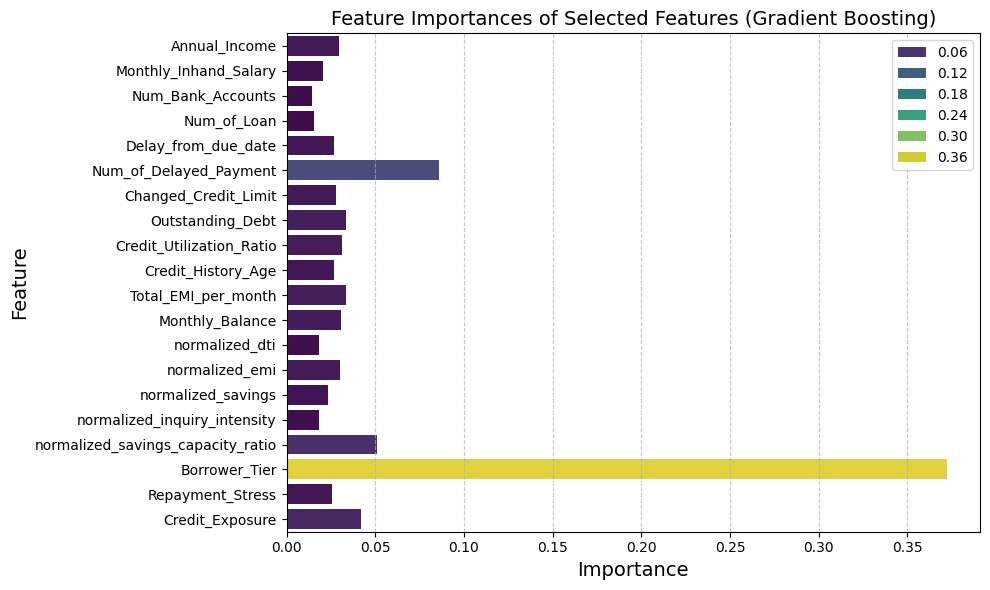

In [165]:
importances = selector.estimator_.feature_importances_
feature_names = X_encoded.columns

selected_mask = selector.get_support()
selected_importances = importances[selected_mask]
selected_feature_names = feature_names[selected_mask]

save_path = "../visualizations/GB_selected_feature_importances.png"

plt.figure(figsize=(10, 6))
sns.barplot(x=selected_importances, y=selected_feature_names, palette="viridis", hue=selected_importances, dodge=False)
plt.title("Feature Importances of Selected Features (Gradient Boosting)", fontsize=14)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(save_path)
plt.show()